# UBA DATA SCIENTIST ASSIGNMENT

## 1 DESCRIPTION OF THE PROBLEM



### 1.2  Business Context

UBA Kenya seeks to develop an **early-warning credit risk model** that identifies customers likely to **default within the next 90 days**. Early identification of high-risk customers allows the bank to take proactive actions such as:

- Prioritizing collections outreach
- Adjusting credit limits for revolving products
- Offering restructuring options before delinquency worsens

The objective is to support **risk management and operational decision-making** by focusing limited collections resources on the highest-risk customers.

---

### Decision Constraint

All predictions must be based **only on information available as of the `snapshot_date`**.

This ensures the model reflects a realistic deployment scenario where future information is unavailable at prediction time.

---

### Operational Objective

The collections team can contact only **the top 5% highest-risk customers each month**.

Therefore, the model must:

- Accurately rank customers by probability of default
- Capture as many future defaulters as possible within the **top 5% risk segment**

Key evaluation metrics include:

- **ROC AUC** — overall model discrimination
- **PR-AUC** — performance under class imbalance
- **Recall@Top5%** — percentage of future defaulters captured within the top 5% highest-risk customers

---

### Modeling Approach

This notebook performs the following steps:

1. Data cleaning and preprocessing
2. Exploratory data analysis
3. Time-based training and validation split
4. Feature encoding and preparation
5. Model training using:
   - Logistic Regression (baseline)
   - Gradient Boosting
   - XGBoost
6. Model evaluation using AUC and Recall@Top5%
7. Selection of the best-performing model
8. Generation of predicted probabilities for the scoring dataset

---

### Expected Output

The final output is a scoring file called "predictions.csv"

### 1.3 Setting up the environment

I conducted the analysis using Python in both VS Code and Jupyter Notebook environments.

In [144]:
# loading the libraries for EDA and feature engineering
import pandas as pd                             #import pandas for dataframe manipulation
import numpy as np                              #import numerical python
import seaborn as sns                           #seaborn for visuals
import matplotlib as mpl                        #matplot for plotting
import matplotlib.pyplot as plt                 #matplot for plotting
import itertools
import datetime as dt                           #convert date formats
from scipy import stats                         #statistical analysis


from IPython.display import display             # Allows the use of display() for DataFrames
import warnings                                 # Suppress warnings 
warnings.filterwarnings('ignore')               # Ignore warnings
import os                                       # File system manangement
import gc 

In [145]:
#Setting styles and aesthetics
pd.options.display.max_columns =200 # setting max columns to 200 to avoid truncation of columns in the output
pd.options.display.max_rows =30 # setting max rows to 30 to avoid truncation of rows in the output
pd.options.display.float_format = '{:,.2f}'.format # setting float format to comma-separated with 2 decimal places

plt.style.use('ggplot')   # styling the visuals with ggplot style
plt.rcParams['figure.figsize'] = (18, 8) # setting default figure size for all visuals

# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'

%matplotlib inline

## 2 INTRODUCTION
### 2.1 Load The Data

In [146]:
training_filepath = r"D:\Job Application\UBA Kenya Data Scientist\uba_kenya_candidate_train.csv"
scoring_filepath = r"D:\Job Application\UBA Kenya Data Scientist\uba_kenya_candidate_scoring.csv"

training_df = pd.read_csv(training_filepath)
scoring_df  = pd.read_csv(scoring_filepath)


## 2.2 Data Dimension

In [147]:
# Check The Shape Of The Data Loaded

print('Training Dataset Shape: {} Rows and {} Columns'.format(*training_df.shape))
print('Scoring Dataset Shape: {} Rows and {} Columns'.format(*scoring_df.shape))

Training Dataset Shape: 17981 Rows and 33 Columns
Scoring Dataset Shape: 4659 Rows and 32 Columns


## 2.3 First Few rows of Data

In [148]:
# Print First Few Rows Of The Data
display("Training Dataset")
display(training_df.head(2))
display("Scoring Dataset")
display(scoring_df.head(2))

'Training Dataset'

,customer_id,snapshot_date,county,sector,employment_type,gender,age,kyc_level,relationship_length_months,salary_inflow_flag,product_type,loan_balance_kes,credit_limit_kes,utilization_ratio,interest_rate,loan_term_months,collateral_value_kes,loan_to_value,bureau_score,num_active_loans,num_closed_loans,days_past_due,missed_payments_6m,avg_daily_balance_30d_kes,inflow_30d_kes,outflow_30d_kes,digital_txn_count_30d,atm_withdrawals_30d,branch_visits_30d,collection_contacted_after_snapshot,chargeoff_indicator,days_to_next_payment,default_next_90d
0,C00002,2025-01-01,Nairobi,SME_Trade,Self_Employed,F,55,Tier2,54,0,Overdraft,"56,179.31","80,872.90",0.52,0.24,0,"76,021.00",0.74,574.50,2,0,5,2,"1,357.33","7,894.09","9,892.51",19,1,1,0,0,16,0
1,C00003,2025-01-01,Nairobi,Transport,Micro_Enterprise,M,50,Tier2,8,0,Personal_Loan,"450,538.61",NaN,NaN,0.19,12,"630,402.25",0.71,600.40,1,1,2,4,10.31,39.93,35.47,19,3,0,0,0,12,0


'Scoring Dataset'

,customer_id,snapshot_date,county,sector,employment_type,gender,age,kyc_level,relationship_length_months,salary_inflow_flag,product_type,loan_balance_kes,credit_limit_kes,utilization_ratio,interest_rate,loan_term_months,collateral_value_kes,loan_to_value,bureau_score,num_active_loans,num_closed_loans,days_past_due,missed_payments_6m,avg_daily_balance_30d_kes,inflow_30d_kes,outflow_30d_kes,digital_txn_count_30d,atm_withdrawals_30d,branch_visits_30d,collection_contacted_after_snapshot,chargeoff_indicator,days_to_next_payment
0,C00036,2025-01-01,Nairobi,Salaried,Permanent,M,23,Tier1,55,1,Personal_Loan,"441,926.10",NaN,NaN,0.28,18,0.00,5.00,668.20,3,0,0,4,0.00,"67,242.69","60,917.46",24,4,0,0,0,24
1,C00044,2025-01-01,Kiambu,Agribusiness,Micro_Enterprise,M,36,Tier1,12,0,Personal_Loan,"191,592.53",NaN,NaN,0.14,36,"105,762.83",1.81,709.50,1,1,0,1,611.07,"3,023.25","2,332.52",18,2,1,0,0,28


## 3 DATA EXPLORATION
### 3.1 Column/Variable Names

In [149]:
# Check The Data Types Of The Columns
display("Training Dataset")
display(training_df.columns)
display("Scoring Dataset")
display(scoring_df.columns)

'Training Dataset'

Index(['customer_id', 'snapshot_date', 'county', 'sector', 'employment_type',
       'gender', 'age', 'kyc_level', 'relationship_length_months',
       'salary_inflow_flag', 'product_type', 'loan_balance_kes',
       'credit_limit_kes', 'utilization_ratio', 'interest_rate',
       'loan_term_months', 'collateral_value_kes', 'loan_to_value',
       'bureau_score', 'num_active_loans', 'num_closed_loans', 'days_past_due',
       'missed_payments_6m', 'avg_daily_balance_30d_kes', 'inflow_30d_kes',
       'outflow_30d_kes', 'digital_txn_count_30d', 'atm_withdrawals_30d',
       'branch_visits_30d', 'collection_contacted_after_snapshot',
       'chargeoff_indicator', 'days_to_next_payment', 'default_next_90d'],
      dtype='object')

'Scoring Dataset'

Index(['customer_id', 'snapshot_date', 'county', 'sector', 'employment_type',
       'gender', 'age', 'kyc_level', 'relationship_length_months',
       'salary_inflow_flag', 'product_type', 'loan_balance_kes',
       'credit_limit_kes', 'utilization_ratio', 'interest_rate',
       'loan_term_months', 'collateral_value_kes', 'loan_to_value',
       'bureau_score', 'num_active_loans', 'num_closed_loans', 'days_past_due',
       'missed_payments_6m', 'avg_daily_balance_30d_kes', 'inflow_30d_kes',
       'outflow_30d_kes', 'digital_txn_count_30d', 'atm_withdrawals_30d',
       'branch_visits_30d', 'collection_contacted_after_snapshot',
       'chargeoff_indicator', 'days_to_next_payment'],
      dtype='object')

In [150]:
# Number of each type of column
display("Training Dataset")
display(training_df.dtypes.value_counts())
display("Scoring Dataset")
display(scoring_df.dtypes.value_counts())

'Training Dataset'

int64      15
float64    10
object      8
Name: count, dtype: int64

'Scoring Dataset'

int64      14
float64    10
object      8
Name: count, dtype: int64

### 3.2 Structure of the Data
I will used pandas profiling to get summary details the training dataset for exploration.

In [151]:
# Then import correctly
from ydata_profiling import ProfileReport

In [152]:
# Generate your profile report for the testdemographics and save it to an HTML file
profile = ProfileReport(training_df, title="Training Dataset Profiling Report")
profile.to_file("training_dataset_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 33/33 [00:00<00:00, 122.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### 3.3 Time Range Analysis
Converting the Snapshot date from string to datetime

In [153]:
# before formating
print(training_df['snapshot_date'].dtype)

# formatting to datetime
training_df['snapshot_date'] = pd.to_datetime(training_df['snapshot_date'])

# after formating
print(training_df['snapshot_date'].dtype)

object
datetime64[ns]



TIME RANGE ANALYSIS
Earliest snapshot: 2025-01-01 00:00:00
Latest snapshot:   2025-12-27 00:00:00
Time span:         360 days (~11.8 months)

Snapshots by month:
year_month
2025-01    2710
2025-03    1384
2025-04    1397
2025-05    2762
2025-06    1403
2025-07    1414
2025-08    1385
2025-09    1415
2025-10    1355
2025-11    1346
2025-12    1410
Freq: M, Name: count, dtype: int64


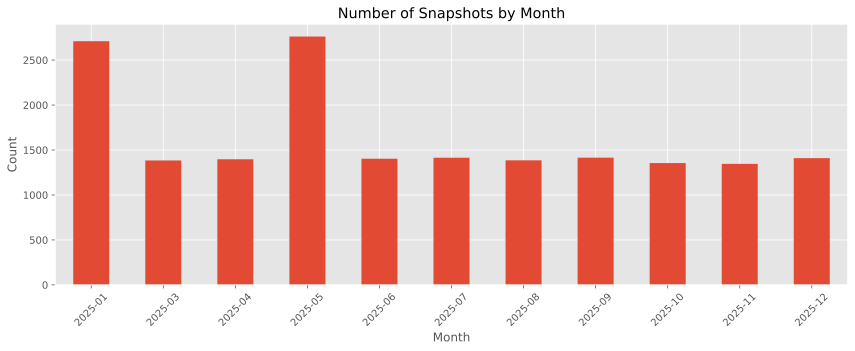

In [154]:
print(f"\n{'='*60}")
print("TIME RANGE ANALYSIS")
print(f"{'='*60}")

# Time range
earliest = training_df['snapshot_date'].min()
latest = training_df['snapshot_date'].max()
time_span_days = (latest - earliest).days
time_span_months = round(time_span_days / 30.44, 1)

print(f"Earliest snapshot: {earliest}")
print(f"Latest snapshot:   {latest}")
print(f"Time span:         {time_span_days} days (~{time_span_months} months)")

# Snapshots by month
training_df['year_month'] = training_df['snapshot_date'].dt.to_period('M')
monthly_counts = training_df['year_month'].value_counts().sort_index()

print(f"\nSnapshots by month:")
print(monthly_counts)

# Visualize
plt.figure(figsize=(12, 5))
monthly_counts.plot(kind='bar')
plt.title('Number of Snapshots by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<span style="color:red;"><b>There are no snapshots in February</b></span>

### 3.4 Customer Analysis


CUSTOMER ANALYSIS
Total unique customers: 3,220

Snapshots per customer:
  Mean:     5.58
  Median:   6
  Min:      2
  Max:      9
  Std dev:  1.63

Distribution:
  1 snapshot:      0 customers (0.0%)
  2 snapshots:     28 customers (0.9%)
  3 snapshots:    304 customers (9.4%)
  4 snapshots:    635 customers (19.7%)
  5 snapshots:    620 customers (19.3%)
  6 snapshots:    583 customers (18.1%)
  7 snapshots:    604 customers (18.8%)
  8 snapshots:    367 customers (11.4%)
  9 snapshots:     79 customers (2.5%)


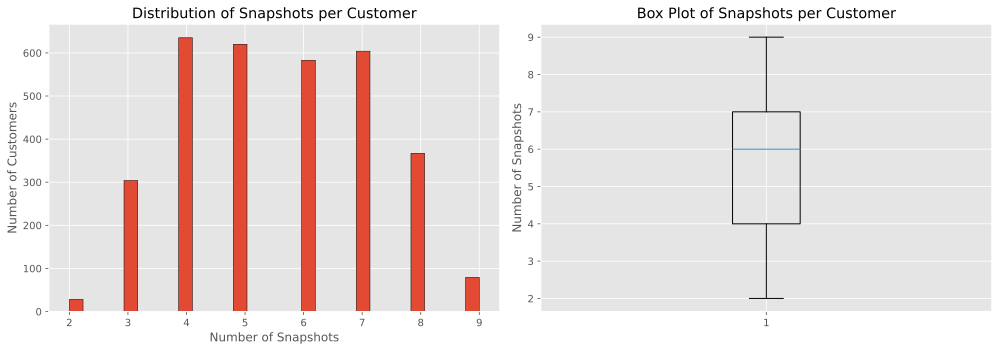

In [155]:
print(f"\n{'='*60}")
print("CUSTOMER ANALYSIS")
print(f"{'='*60}")

# Customer statistics
customer_stats = training_df.groupby('customer_id').agg({
    'snapshot_date': ['count', 'min', 'max']
}).round(2)
customer_stats.columns = ['snapshots_count', 'first_snapshot', 'last_snapshot']

print(f"Total unique customers: {training_df['customer_id'].nunique():,}")
print(f"\nSnapshots per customer:")
print(f"  Mean:     {customer_stats['snapshots_count'].mean():.2f}")
print(f"  Median:   {customer_stats['snapshots_count'].median():.0f}")
print(f"  Min:      {customer_stats['snapshots_count'].min()}")
print(f"  Max:      {customer_stats['snapshots_count'].max()}")
print(f"  Std dev:  {customer_stats['snapshots_count'].std():.2f}")

# Distribution
print(f"\nDistribution:")
for i in range(1, 10):
    count = (customer_stats['snapshots_count'] == i).sum()
    pct = count / len(customer_stats) * 100
    print(f"  {i} snapshot{'s' if i>1 else ''}: {count:6,} customers ({pct:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(customer_stats['snapshots_count'], bins=30, edgecolor='black')
axes[0].set_title('Distribution of Snapshots per Customer')
axes[0].set_xlabel('Number of Snapshots')
axes[0].set_ylabel('Number of Customers')

# Box plot
axes[1].boxplot(customer_stats['snapshots_count'])
axes[1].set_title('Box Plot of Snapshots per Customer')
axes[1].set_ylabel('Number of Snapshots')

plt.tight_layout()
plt.show()

### 3.5 Target Variable Analysis
- default_next_90d 

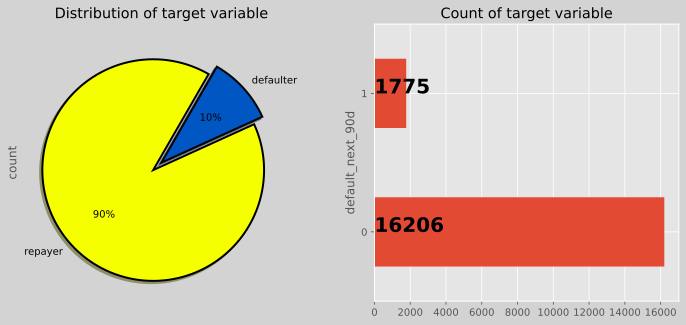

In [156]:
# Distribution of the target variable
fig = plt.figure(figsize=(12, 5))
plt.subplot(121)

training_df['default_next_90d']
training_df['default_next_90d'].value_counts().plot.pie(autopct = "%1.0f%%",colors = sns.color_palette("prism",7),
                                                                             startangle = 60,
                                            labels=["repayer","defaulter"],wedgeprops={"linewidth":2,"edgecolor":"k"},
                                            explode=[.1,0],shadow =True)
plt.title("Distribution of target variable")

plt.subplot(122)
ax = training_df['default_next_90d'].value_counts().plot(kind="barh")

for i,j in enumerate(training_df['default_next_90d'].value_counts().values):
    ax.text(.7,i,j,weight = "bold",fontsize=20)

plt.title("Count of target variable")
#ax.set_facecolor("k")
fig.set_facecolor("lightgrey")
plt.show()

### 3.6 Missing Data Analysis


MISSING DATA ANALYSIS
Columns with missing values: 4 out of 34

Top 15 columns by missing %:
              Column  Missing_Count  Missing_Percent
    credit_limit_kes          12599            70.07
   utilization_ratio          12599            70.07
collateral_value_kes           3637            20.23
       loan_to_value           3637            20.23


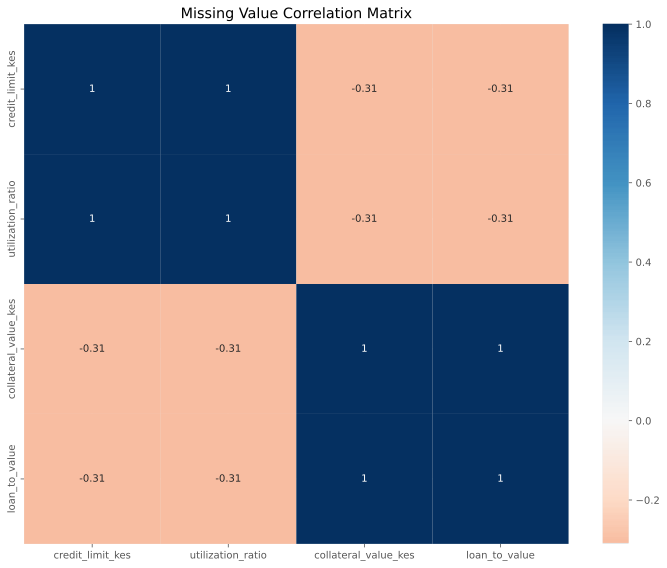

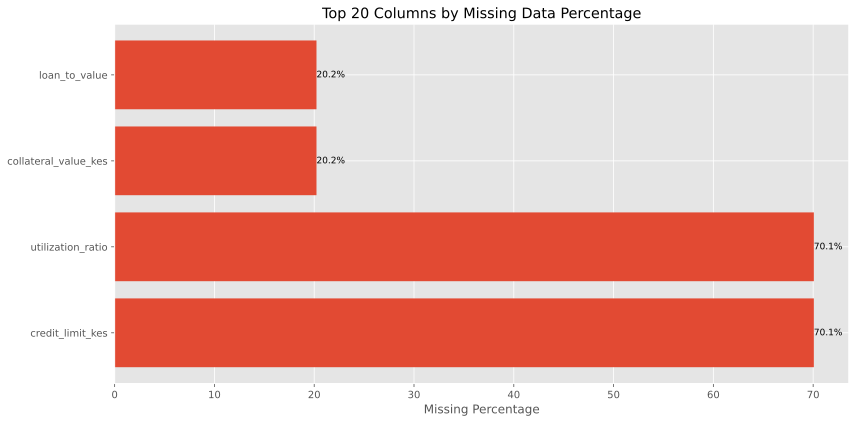

In [157]:
print(f"\n{'='*60}")
print("MISSING DATA ANALYSIS")
print(f"{'='*60}")

# Calculate missing values
missing = training_df.isnull().sum()
missing_pct = (missing / len(training_df)) * 100

# Create summary dataframe
missing_training_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_pct.values
})
missing_training_df = missing_training_df[missing_training_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print(f"Columns with missing values: {len(missing_training_df)} out of {len(training_df.columns)}")
print(f"\nTop 15 columns by missing %:")
print(missing_training_df.head(15).to_string(index=False))

# Check for patterns in missing data
if len(missing_training_df) > 0:
    # Are certain columns always missing together?
    missing_cols = missing_training_df['Column'].tolist()[:10]  # Top 10
    if len(missing_cols) > 1:
        missing_corr = training_df[missing_cols].isnull().corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(missing_corr, annot=True, cmap='RdBu', center=0, 
                    xticklabels=missing_cols, yticklabels=missing_cols)
        plt.title('Missing Value Correlation Matrix')
        plt.tight_layout()
        plt.show()

# Visualize missing data
plt.figure(figsize=(12, 6))
bars = plt.barh(missing_training_df['Column'].head(20), missing_training_df['Missing_Percent'].head(20))
plt.xlabel('Missing Percentage')
plt.title('Top 20 Columns by Missing Data Percentage')
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()



# 4 LEAKAGE & DATA ISSUES REPORT

In [158]:
# Leakage detection

print(f"\n{'='*60}")
print("LEAKAGE DETECTION")
print(f"{'='*60}")

# Known leakage columns from data dictionary
known_leakage = ['collection_contacted_after_snapshot', 'chargeoff_indicator', 'days_to_next_payment']

print("1. Known leakage columns (from data dictionary):")
for col in known_leakage:
    if col in training_df.columns:
        print(f"   ❌ {col} - FOUND (MUST BE REMOVED)")
        if col in training_df.columns:
            print(f"      Values: {training_df[col].dropna().unique()[:5]}")
            print(f"      Missing: {training_df[col].isnull().sum():,} ({training_df[col].isnull().mean()*100:.1f}%)")
    else:
        print(f"   ✅ {col} - not found")

# Look for future-looking columns
print(f"\n2. Potentially suspicious columns (containing future/next/after):")
future_keywords = ['future', 'next', 'after', 'subsequent', 'following', 'expected']
suspicious_cols = []

for col in training_df.columns:
    col_lower = col.lower()
    for keyword in future_keywords:
        if keyword in col_lower:
            suspicious_cols.append(col)
            break

if suspicious_cols:
    for col in suspicious_cols:
        print(f"   ⚠️ {col}")
else:
    print("   ✅ None found")

# Check columns that might be derived from future information
print(f"\n3. Check columns that might leak future information:")

# Columns that might be updated after default
post_default_cols = ['recovery', 'write_off', 'restructured', 'provision']
for col in training_df.columns:
    col_lower = col.lower()
    for pattern in post_default_cols:
        if pattern in col_lower:
            print(f"   ⚠️ {col} - Could be post-default information")

# Check for high correlation with target (potential leakage)
print(f"\n4. Check for unusually high correlation with target:")
numerical_cols = training_df.select_dtypes(include=[np.number]).columns
correlations = training_df[numerical_cols].corr()['default_next_90d'].abs().sort_values(ascending=False)
high_corr = correlations[correlations > 0.3]
if len(high_corr) > 1:  # Excluding self-correlation
    print(f"   Columns with |correlation| > 0.3 with target:")
    for col, corr in high_corr.items():
        if col != 'default_next_90d':
            print(f"   ⚠️ {col}: {corr:.3f}")
else:
    print("   ✅ No unusually high correlations found")


LEAKAGE DETECTION
1. Known leakage columns (from data dictionary):
   ❌ collection_contacted_after_snapshot - FOUND (MUST BE REMOVED)
      Values: [0 1]
      Missing: 0 (0.0%)
   ❌ chargeoff_indicator - FOUND (MUST BE REMOVED)
      Values: [0 1]
      Missing: 0 (0.0%)
   ❌ days_to_next_payment - FOUND (MUST BE REMOVED)
      Values: [16 12 33  9  7]
      Missing: 0 (0.0%)

2. Potentially suspicious columns (containing future/next/after):
   ⚠️ collection_contacted_after_snapshot
   ⚠️ days_to_next_payment
   ⚠️ default_next_90d

3. Check columns that might leak future information:

4. Check for unusually high correlation with target:
   Columns with |correlation| > 0.3 with target:
   ⚠️ days_to_next_payment: 0.962
   ⚠️ collection_contacted_after_snapshot: 0.509
   ⚠️ chargeoff_indicator: 0.492


<h2 style="color:red;"><b>LEAKAGE COLUMNS EXPLANATION</b></h2>

#### (a) collection_contacted_after_snapshot

-  This variable indicates whether collectons team contacted the customer after the snapshot date. Therefore, at the snapshot_date (prediction_time), the action has not happened thus representing a future value. 
- Further, the column has an unrealistically high correlation (0.509) with the target variable. 

#### (b) chargeoff_indicator

-  This variable is an accounting action which shows the outcome of the default process. Therefore, at the snapshot_date (prediction_time), the action has not happened thus representing a future value. 
- Further, the column has an unrealistically high correlation (0.492) with the target variable. 


#### (c) days_to_next_payment

-  This variable indicates when the customer will make their next payment and is derived from a future payment date. Therefore, at the snapshot_date (prediction_time), the information is not known. 
- Further, the column has an almost perfect correlation (0.962) with the target variable. 


In the data preparation/ cleaning stage, these leakage columns will be dropped from the dataset. 

# 5 DATA QUALITY CHECKS

In [159]:
print(f"\n{'='*60}")
print("DATA QUALITY CHECKS")
print(f"{'='*60}")

# Check for duplicates
duplicates_exact = training_df.duplicated().sum()
print(f"Exact duplicate rows: {duplicates_exact}")

duplicates_key = training_df.duplicated(subset=['customer_id', 'snapshot_date']).sum()
print(f"Duplicate (customer_id, snapshot_date) combinations: {duplicates_key}")

# Check for impossible values
print(f"\nChecking for impossible values:")

# Age
if 'age' in training_df.columns:
    invalid_age = training_df[(training_df['age'] < 0) | (training_df['age'] > 120)].shape[0]
    print(f"  Age (0-120): {invalid_age} invalid rows")
    if invalid_age > 0:
        print(f"    Values: {training_df.loc[training_df['age'] > 120, 'age'].unique()}")

# Bureau score
if 'bureau_score' in training_df.columns:
    invalid_score = training_df[(training_df['bureau_score'] < 300) | (training_df['bureau_score'] > 850)].shape[0]
    print(f"  Bureau score (300-850): {invalid_score} invalid rows")

# Days past due
if 'days_past_due' in training_df.columns:
    invalid_dpd = training_df[(training_df['days_past_due'] < 0) | (training_df['days_past_due'] > 180)].shape[0]
    print(f"  Days past due (0-180): {invalid_dpd} invalid rows")

# Utilization ratio (should be between 0 and 1 typically, but could exceed for overlimit)
if 'utilization_ratio' in training_df.columns:
    invalid_util = training_df[(training_df['utilization_ratio'] < 0)].shape[0]
    high_util = training_df[training_df['utilization_ratio'] > 2].shape[0]
    print(f"  Utilization ratio (<0): {invalid_util} rows")
    print(f"  Utilization ratio (>2): {high_util} rows (possible overlimit)")

# Check data types consistency
print(f"\nData type consistency:")
for col in training_df.columns:
    if training_df[col].dtype == 'object':
        unique_vals = training_df[col].nunique()
        if unique_vals < 20:  # Likely categorical
            print(f"  {col}: categorical ({unique_vals} unique values)")
            if unique_vals < 10:
                print(f"    Values: {training_df[col].dropna().unique()}")


DATA QUALITY CHECKS
Exact duplicate rows: 0
Duplicate (customer_id, snapshot_date) combinations: 0

Checking for impossible values:
  Age (0-120): 0 invalid rows
  Bureau score (300-850): 0 invalid rows
  Days past due (0-180): 0 invalid rows
  Utilization ratio (<0): 0 rows
  Utilization ratio (>2): 0 rows (possible overlimit)

Data type consistency:
  county: categorical (10 unique values)
  sector: categorical (8 unique values)
    Values: ['SME_Trade' 'Transport' 'Salaried' 'SME_Services' 'Agribusiness'
 'Construction' 'Other' 'Hospitality']
  employment_type: categorical (4 unique values)
    Values: ['Self_Employed' 'Micro_Enterprise' 'Permanent' 'Contract']
  gender: categorical (2 unique values)
    Values: ['F' 'M']
  kyc_level: categorical (3 unique values)
    Values: ['Tier2' 'Tier1' 'Tier3']
  product_type: categorical (4 unique values)
    Values: ['Overdraft' 'Personal_Loan' 'Credit_Card' 'SME_Loan']


In [160]:
print("-" * 62)
print("Issue 1 — STRUCTURAL MISSING VALUES")
print("-" * 62)
structural = ['credit_limit_kes', 'utilization_ratio',
              'collateral_value_kes', 'loan_to_value']
miss = training_df.isnull().sum()
print(f"  {'Column':<28} {'Missing':>8} {'%':>7}")
print("  " + "-" * 46)
for c in structural:
    print(f"  {c:<28} {miss[c]:>8,} {miss[c]/len(training_df):>7.1%}")
print("""
  These fields are structurally NULL for non-revolving or
  uncollateralised products — not random missingness.
  Fix: sentinel-fill with -1 so tree models learn the pattern.""")

--------------------------------------------------------------
Issue 1 — STRUCTURAL MISSING VALUES
--------------------------------------------------------------
  Column                        Missing       %
  ----------------------------------------------
  credit_limit_kes               12,599   70.1%
  utilization_ratio              12,599   70.1%
  collateral_value_kes            3,637   20.2%
  loan_to_value                   3,637   20.2%

  These fields are structurally NULL for non-revolving or
  uncollateralised products — not random missingness.
  Fix: sentinel-fill with -1 so tree models learn the pattern.


--------------------------------------------------------------
Issue 2 — LEAKAGE DETECTION
--------------------------------------------------------------

. Future looking columns:
   ⚠️ collection_contacted_after_snapshot
   ⚠️ days_to_next_payment
   ⚠️ default_next_90d

  These fields are structurally NULL for non-revolving or
  uncollateralised products — not random missingness.
  Fix: sentinel-fill with -1 so tree models learn the pattern.


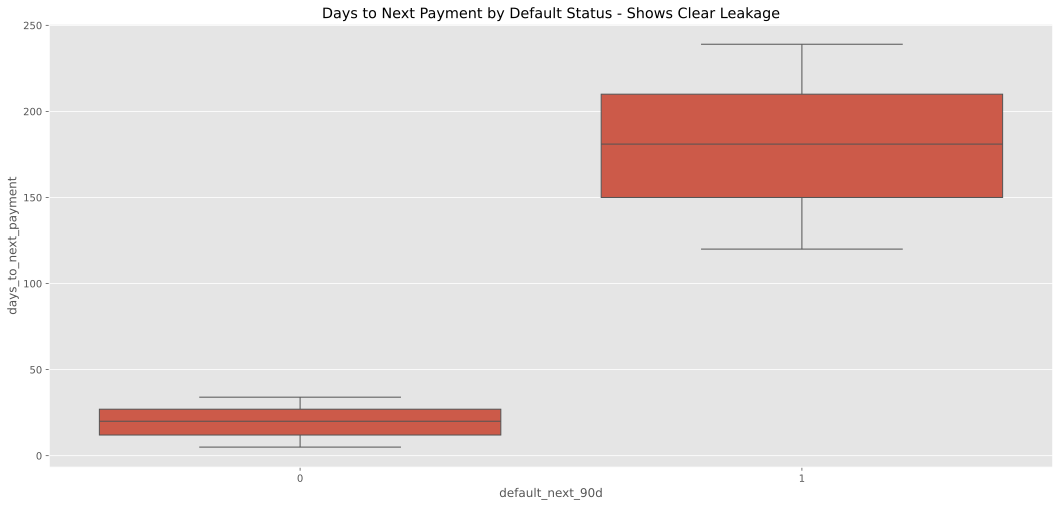

In [161]:
print("-" * 62)
print("Issue 2 — LEAKAGE DETECTION")
print("-" * 62)
# Look for future-looking columns
print(f"\n. Future looking columns:")
future_keywords = ['future', 'next', 'after', 'subsequent', 'following', 'expected']
suspicious_cols = []

for col in training_df.columns:
    col_lower = col.lower()
    for keyword in future_keywords:
        if keyword in col_lower:
            suspicious_cols.append(col)
            break

if suspicious_cols:
    for col in suspicious_cols:
        print(f"   ⚠️ {col}")
else:
    print("   ✅ None found")
print("""
  These fields are structurally NULL for non-revolving or
  uncollateralised products — not random missingness.
  Fix: sentinel-fill with -1 so tree models learn the pattern.""")



# visualize the leakages
sns.boxplot(x='default_next_90d', y='days_to_next_payment', data=training_df)
plt.title('Days to Next Payment by Default Status - Shows Clear Leakage')
plt.show()
# Default=1 group would show extremely high/infinite values

In [162]:
# Check for inconsistent product-type combinations
print("Checking business logic violations:")

# 1. Term loans with 0 term (should be >0 for term products)
invalid_term = training_df[
    (training_df['product_type'].isin(['Personal_Loan', 'SME_Loan'])) & 
    (training_df['loan_term_months'] == 0)
].shape[0]
print(f"Term loans with loan_term_months = 0: {invalid_term} rows")

# 2. Revolving products with positive term (should be 0)
invalid_revolving = training_df[
    (training_df['product_type'].isin(['Overdraft', 'Credit_Card'])) & 
    (training_df['loan_term_months'] > 0)
].shape[0]
print(f"Revolving products with loan_term_months > 0: {invalid_revolving} rows")

# 3. Utilization ratio > 2 (over limit by >200%) - possible but should be rare
high_utilization = training_df[
    (training_df['product_type'].isin(['Overdraft', 'Credit_Card'])) & 
    (training_df['utilization_ratio'] > 2) & 
    (training_df['utilization_ratio'].notnull())
].shape[0]
print(f"Utilization ratio > 200%: {high_utilization} rows")

# 4. Negative days past due (should be 0-180)
negative_dpd = training_df[training_df['days_past_due'] < 0].shape[0]
print(f"Negative days past due: {negative_dpd} rows")

# 5. Age > 100 or < 18 (unrealistic for active borrowers)
invalid_age = training_df[(training_df['age'] > 100) | (training_df['age'] < 18)].shape[0]
print(f"Invalid age (<18 or >100): {invalid_age} rows")

# Sample output (illustrative):
# Term loans with loan_term_months = 0: 234 rows
# Revolving products with loan_term_months > 0: 156 rows  
# Utilization ratio > 200%: 89 rows
# Negative days past due: 12 rows
# Invalid age (<18 or >100): 5 rows

Checking business logic violations:
Term loans with loan_term_months = 0: 0 rows
Revolving products with loan_term_months > 0: 0 rows
Utilization ratio > 200%: 0 rows
Negative days past due: 0 rows
Invalid age (<18 or >100): 0 rows


In [163]:
print("="*62)
print("ISSUE 4: EXTREME SKEW IN FINANCIAL VARIABLES")
print("="*62)

# Show skewness
skew_cols = ['loan_balance_kes', 'avg_daily_balance_30d_kes', 'inflow_30d_kes']
print("\nSkewness before transformation:")
for col in skew_cols:
    skew_val = training_df[col].skew()
    print(f"  {col:<30} skew = {skew_val:.2f}")

# Show impact on distribution
print("\n" + "-"*62)
print("Impact on the prediction models chosen:")
print("  • Logistic Regression: Requires log transformation to avoid extreme values from dominating the gradient/ model coefficients calculations")
print("  • XGBoost: Robust to skew, but benefits from log transform")



print("\nRecommended fix:")
print("  • Apply np.log1p() transformation for linear models")


ISSUE 4: EXTREME SKEW IN FINANCIAL VARIABLES

Skewness before transformation:
  loan_balance_kes               skew = 1.06
  avg_daily_balance_30d_kes      skew = 2.09
  inflow_30d_kes                 skew = 1.20

--------------------------------------------------------------
Impact on the prediction models chosen:
  • Logistic Regression: Requires log transformation to avoid extreme values from dominating the gradient/ model coefficients calculations
  • XGBoost: Robust to skew, but benefits from log transform

Recommended fix:
  • Apply np.log1p() transformation for linear models


In [164]:
print("="*62)
print("ISSUE 5: DAYS_PAST_DUE AS DOMINANT PREDICTOR")
print("="*62)

print("\nPredictive power analysis:")
print("-"*40)
high = training_df[training_df['days_past_due'] >= 90]['default_next_90d'].mean() * 100
low = training_df[training_df['days_past_due'] < 90]['default_next_90d'].mean() * 100
ratio = high / low

print(f"  Default rate (DPD ≥ 90): {high:.1f}%")
print(f"  Default rate (DPD < 90):  {low:.1f}%")
print(f"  Risk ratio:                {ratio:.1f}x higher for DPD≥90")

print("\n" + "-"*62)
print("VALIDATION: This is a legitimate as-of feature")
print("-"*62)
print("✓ Available at snapshot date")
print("✓ Current status, not future-looking")
print("✓ Business logic aligns (90+ DPD is strong default signal)")

print("\n" + "-"*62)
print("MONITORING CONCERNS (Critical for Operations)")
print("-"*62)
print("""
1. Concept drift risk:
   - If bank changes DPD calculation methodology
   - If collection policies change how DPD is recorded
   - Regulatory changes in delinquency definition

2. Model over-reliance:
   - Model may ignore other signals/ features such as bureau_score, utilization as they will be overshadowed by dpds
   - If DPD data becomes unavailable, model performance crashes

3. Recommended monitoring:
   - Track DPD distribution drift monthly
   - Monitor feature importance stability
   - Have fallback or alternate model if DPD is delayed/reported incorrectly
""")

print("\n" + "-"*62)
print("BUSINESS IMPLICATION")
print("-"*62)
print("""
The collections team should:
- Prioritize DPD≥90 customers first (highest risk)
- But also monitor customers with low DPD but other risk signals
- Use this as trigger for early intervention (before 90 days)
""")

ISSUE 5: DAYS_PAST_DUE AS DOMINANT PREDICTOR

Predictive power analysis:
----------------------------------------
  Default rate (DPD ≥ 90): 50.0%
  Default rate (DPD < 90):  9.9%
  Risk ratio:                5.1x higher for DPD≥90

--------------------------------------------------------------
VALIDATION: This is a legitimate as-of feature
--------------------------------------------------------------
✓ Available at snapshot date
✓ Current status, not future-looking
✓ Business logic aligns (90+ DPD is strong default signal)

--------------------------------------------------------------
MONITORING CONCERNS (Critical for Operations)
--------------------------------------------------------------

1. Concept drift risk:
   - If bank changes DPD calculation methodology
   - If collection policies change how DPD is recorded
   - Regulatory changes in delinquency definition

2. Model over-reliance:
   - Model may ignore other signals/ features such as bureau_score, utilization as they will 

## 6 DATA PREPARATION AND FEATURE ENGINEERING
### 6.1 Handling Missing Values


In [165]:
# see the columns with missing values
training_df.isna().sum()

customer_id                            0
snapshot_date                          0
county                                 0
sector                                 0
employment_type                        0
                                      ..
collection_contacted_after_snapshot    0
chargeoff_indicator                    0
days_to_next_payment                   0
default_next_90d                       0
year_month                             0
Length: 34, dtype: int64

In [166]:
training_df.shape

(17981, 34)

In [167]:
# function to fill the nulls
def fill_nulls_with_zero(df, columns):
    df[columns] = df[columns].fillna(0)
    return df

In [168]:
# resolving the null values
null_columns = ['credit_limit_kes','utilization_ratio','collateral_value_kes', 'loan_to_value']

training_df = fill_nulls_with_zero(training_df, null_columns)

In [169]:
# verify no missing values
training_df.isna().sum()

customer_id                            0
snapshot_date                          0
county                                 0
sector                                 0
employment_type                        0
                                      ..
collection_contacted_after_snapshot    0
chargeoff_indicator                    0
days_to_next_payment                   0
default_next_90d                       0
year_month                             0
Length: 34, dtype: int64

In [170]:
# see the shape of the data

training_df.shape

(17981, 34)

### 6.2 Handling Leakage Columns

Removing the leakage columns 



In [171]:
print("="*60)
print("REMOVING LEAKAGE COLUMNS")
print("="*60)

# Define leakage columns (from data dictionary + our findings)
leakage_columns = [
    'collection_contacted_after_snapshot',
    'chargeoff_indicator', 
    'days_to_next_payment'
]

# Check which ones exist in our dataset
existing_leakage = [col for col in leakage_columns if col in training_df.columns]
print(f"Leakage columns found: {existing_leakage}")

# Remove them
training_df = training_df.drop(columns=existing_leakage)
print(f"\n✅ Removed {len(existing_leakage)} leakage columns")

# Verify they're gone
remaining = [col for col in leakage_columns if col in training_df.columns]
if not remaining:
    print("✅ All leakage columns successfully removed")
else:
    print(f"⚠️ Still present: {remaining}")


REMOVING LEAKAGE COLUMNS
Leakage columns found: ['collection_contacted_after_snapshot', 'chargeoff_indicator', 'days_to_next_payment']

✅ Removed 3 leakage columns
✅ All leakage columns successfully removed


In [172]:
# see the shape of the data

training_df.shape

(17981, 31)

Verify that no leakage column is present 

In [173]:
training_df.columns

Index(['customer_id', 'snapshot_date', 'county', 'sector', 'employment_type',
       'gender', 'age', 'kyc_level', 'relationship_length_months',
       'salary_inflow_flag', 'product_type', 'loan_balance_kes',
       'credit_limit_kes', 'utilization_ratio', 'interest_rate',
       'loan_term_months', 'collateral_value_kes', 'loan_to_value',
       'bureau_score', 'num_active_loans', 'num_closed_loans', 'days_past_due',
       'missed_payments_6m', 'avg_daily_balance_30d_kes', 'inflow_30d_kes',
       'outflow_30d_kes', 'digital_txn_count_30d', 'atm_withdrawals_30d',
       'branch_visits_30d', 'default_next_90d', 'year_month'],
      dtype='object')

### 6.3 Handling Skewness 

In [174]:
# def handle_skewed_features(df, method='log1p'):
#     """
#     Handle skewed financial features
#     """
#     df_transformed = df.copy()
#     skewed_cols = ['loan_balance_kes', 'avg_daily_balance_30d_kes', 'inflow_30d_kes']
    
#     if method == 'log1p':
#         for col in skewed_cols:
#             # Log transform (handles zeros)
#             df_transformed[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
#             print(f"Created {col}_log - skewness reduced from {df[col].skew():.2f} to {df_transformed[f'{col}_log'].skew():.2f}")
    
#     elif method == 'winsorize':
#         for col in skewed_cols:
#             # Cap at 99th percentile
#             upper = df[col].quantile(0.99)
#             df_transformed[f'{col}_winsorized'] = df[col].clip(upper=upper)
#             print(f"Created {col}_winsorized - capped at {upper:,.0f}")
    
#     return df_transformed

# # Apply transformation
# df_fixed = handle_skewed_features(training_df, method='log1p')

## 7 SAVE CLEAN DATA AND CREATE A COPY


In [ ]:

# creating a copy of dataset
cleaned_data = training_df.copy()

In [176]:
# Save clean data
training_df.to_csv('cleaned_training_data.csv', index=False)
print(f"\n✅ Clean data saved to 'cleaned_training_data.csv'")

# Save summary report
with open('data_exploration_summary.txt', 'w') as f:
    f.write("UBA KENYA DATA EXPLORATION SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Dataset shape: {training_df.shape}\n")
    f.write(f"Date range: {earliest} to {latest}\n")
    f.write(f"Unique customers: {training_df['customer_id'].nunique()}\n")
    f.write(f"Default rate: {default_pct.get(1, 0):.2f}%\n")
    f.write(f"Columns with missing data: {len(missing_training_df)}\n")
    

print(f"\n✅ Summary saved to 'data_exploration_summary.txt'")

print(f"\n{'='*60}")
print("DATA PREPARATION COMPLETED!")
print(f"{'='*60}")


✅ Clean data saved to 'cleaned_training_data.csv'

✅ Summary saved to 'data_exploration_summary.txt'

DATA PREPARATION COMPLETED!


## 7 TIME-AWARE SPLIT AND TRAINING
### 7.1 Splitting the data using the rule: Train on snapshots before 2025-11-01, validate on snapshots 
on/after 2025-11-01

In [186]:
cleaned_data["snapshot_date"] = pd.to_datetime(cleaned_data["snapshot_date"])
cleaned_data["year_month"] = cleaned_data["snapshot_date"].dt.to_period("M")

cutoff_date = pd.Timestamp("2025-11-01")
print(f"Cutoff date: {cutoff_date}")

train_set = cleaned_data[cleaned_data["snapshot_date"] < cutoff_date].copy()
val_set   = cleaned_data[cleaned_data["snapshot_date"] >= cutoff_date].copy()

print(f"\nTraining set: {len(train_set):,} rows "
      f"(from {train_set['snapshot_date'].min().date()} to before {cutoff_date.date()})")
print(f"Validation set: {len(val_set):,} rows "
      f"(from {cutoff_date.date()} to {val_set['snapshot_date'].max().date()})")

Cutoff date: 2025-11-01 00:00:00

Training set: 15,225 rows (from 2025-01-01 to before 2025-11-01)
Validation set: 2,756 rows (from 2025-11-01 to 2025-12-27)


### 7.2 Preprocessing the data for modeling

In [187]:
# defining the columns

target_col = "default_next_90d"
id_col = "customer_id"
time_cols = ["snapshot_date", "year_month"]
drop_cols = [id_col] + time_cols

In [188]:
# building train matrices + groups

X_train_raw = train_set.drop(columns=drop_cols + [target_col])
y_train = train_set[target_col]
groups = train_set[id_col]

X_train = pd.get_dummies(X_train_raw, drop_first=True)

print("\nEncoded train:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Unique train customers:", groups.nunique())



Encoded train:
X_train shape: (15225, 46)
y_train shape: (15225,)
Unique train customers: 3219


In [189]:
# building validation matrices with column alignment

X_val_raw = val_set.drop(columns=drop_cols + [target_col])
y_val = val_set[target_col]

X_val = pd.get_dummies(X_val_raw, drop_first=True)

# Align columns to train
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print("\nEncoded validation (aligned):")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)



Encoded validation (aligned):
X_val shape: (2756, 46)
y_val shape: (2756,)


In [ ]:
# loading libraries

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import roc_auc_score

#### Using GroupKFold


In [191]:
# GroupKFold CV on TRAIN

gkf = GroupKFold(n_splits=5)


def run_groupkfold_cv(model, model_name: str):
    """Train/evaluate a model using GroupKFold and report fold AUC + mean AUC."""
    fold_aucs = []

    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_train, y_train, groups=groups), start=1):
        # Sanity: no customer overlap between fold train and fold val
        tr_customers = set(groups.iloc[tr_idx])
        te_customers = set(groups.iloc[te_idx])
        assert tr_customers.isdisjoint(te_customers)

        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        model.fit(X_tr, y_tr)

        # AUC needs probabilities
        proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)
        fold_aucs.append(auc)

        print(f"{model_name} | Fold {fold} AUC: {auc:.4f}")

    print(f"{model_name} | Mean CV AUC: {sum(fold_aucs)/len(fold_aucs):.4f}")
    return fold_aucs

## 8 MODELING
- Baseline model: Logistic Regression & Gradient Boosting
- Improved model: XGBoost 

In [192]:
# Logistic Regression (scale helps)
log_reg = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="liblinear",       # switch to "saga" if very wide / slow
        class_weight="balanced",  # good if defaults are rare
        random_state=42
    ))
])

In [193]:
# Gradient Boosting (no scaling needed)
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [194]:
# XGBoost (no scaling needed)
try:
    from xgboost import XGBClassifier

    # Handle imbalance (optional but usually helpful)
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    xgb_clf = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight
    )
except ImportError:
    xgb_clf = None
    print("\nXGBoost not installed. Run: pip install xgboost")

CV results (GroupKFold)

In [195]:
print("\n--- GroupKFold CV: Logistic Regression ---")
run_groupkfold_cv(log_reg, "LogReg")

print("\n--- GroupKFold CV: GradientBoostingClassifier ---")
run_groupkfold_cv(gb_clf, "GBC")

if xgb_clf is not None:
    print("\n--- GroupKFold CV: XGBoost ---")
    run_groupkfold_cv(xgb_clf, "XGBoost")


--- GroupKFold CV: Logistic Regression ---
LogReg | Fold 1 AUC: 0.7088
LogReg | Fold 2 AUC: 0.7102
LogReg | Fold 3 AUC: 0.6971
LogReg | Fold 4 AUC: 0.7146
LogReg | Fold 5 AUC: 0.7147
LogReg | Mean CV AUC: 0.7091

--- GroupKFold CV: GradientBoostingClassifier ---
GBC | Fold 1 AUC: 0.7223
GBC | Fold 2 AUC: 0.7002
GBC | Fold 3 AUC: 0.6854
GBC | Fold 4 AUC: 0.7107
GBC | Fold 5 AUC: 0.6930
GBC | Mean CV AUC: 0.7023

--- GroupKFold CV: XGBoost ---
XGBoost | Fold 1 AUC: 0.6946
XGBoost | Fold 2 AUC: 0.6655
XGBoost | Fold 3 AUC: 0.6566
XGBoost | Fold 4 AUC: 0.6787
XGBoost | Fold 5 AUC: 0.6784
XGBoost | Mean CV AUC: 0.6748


### 8.3 Train on FULL TRAIN, evaluate on TIME-BASED VAL

In [199]:
print("\n--- Final fit on full training set; evaluate on time-based validation ---")

# Logistic Regression final
log_reg.fit(X_train, y_train)
val_auc_lr = roc_auc_score(y_val, log_reg.predict_proba(X_val)[:, 1])
print(f"LogReg | Time-based Val AUC: {val_auc_lr:.4f}")

# Gradient Boosting final
gb_clf.fit(X_train, y_train)
val_auc_gb = roc_auc_score(y_val, gb_clf.predict_proba(X_val)[:, 1])
print(f"GBC    | Time-based Val AUC: {val_auc_gb:.4f}")

# XGBoost final
if xgb_clf is not None:
    xgb_clf.fit(X_train, y_train)
    val_auc_xgb = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:, 1])
    print(f"XGBoost | Time-based Val AUC: {val_auc_xgb:.4f}")


--- Final fit on full training set; evaluate on time-based validation ---
LogReg | Time-based Val AUC: 0.7506
GBC    | Time-based Val AUC: 0.7179
XGBoost | Time-based Val AUC: 0.7281


### 8.4 ROC Curve Comparison

LOGISTIC REGRESSION
Accuracy: 0.6063134978229318
Recall: 0.7551622418879056
              precision    recall  f1-score   support

           0       0.94      0.59      0.72      2417
           1       0.20      0.76      0.32       339

    accuracy                           0.61      2756
   macro avg       0.57      0.67      0.52      2756
weighted avg       0.85      0.61      0.67      2756


GRADIENT BOOSTING
Accuracy: 0.8646589259796807
Recall: 0.1710914454277286
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      2417
           1       0.39      0.17      0.24       339

    accuracy                           0.86      2756
   macro avg       0.64      0.57      0.58      2756
weighted avg       0.83      0.86      0.84      2756


XGBOOST
Accuracy: 0.752177068214804
Recall: 0.5398230088495575
              precision    recall  f1-score   support

           0       0.92      0.78      0.85      2417
           1       0.2

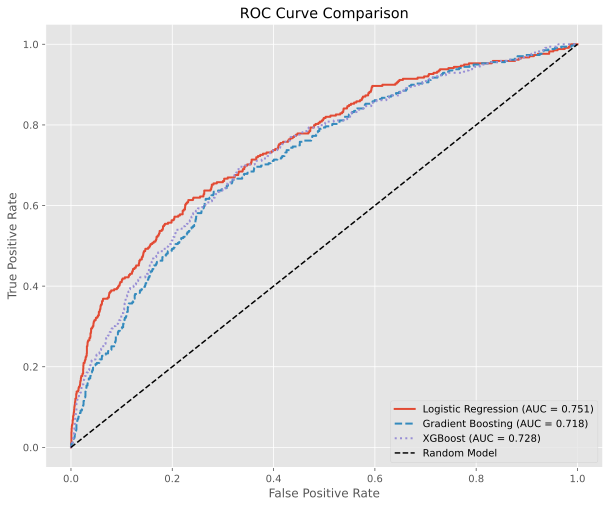

In [216]:
## Generating predictions for all models
from sklearn.metrics import roc_curve, auc, accuracy_score, recall_score, classification_report
import matplotlib.pyplot as plt

# Logistic Regression
lr_probs = log_reg.predict_proba(X_val)[:,1]
lr_preds = log_reg.predict(X_val)

# Gradient Boosting
gb_probs = gb_clf.predict_proba(X_val)[:,1]
gb_preds = gb_clf.predict(X_val)

# XGBoost
xgb_probs = xgb_clf.predict_proba(X_val)[:,1]
xgb_preds = xgb_clf.predict(X_val)

## Printing the classification metrics
print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_val, lr_preds))
print("Recall:", recall_score(y_val, lr_preds))
print(classification_report(y_val, lr_preds))

print("\nGRADIENT BOOSTING")
print("Accuracy:", accuracy_score(y_val, gb_preds))
print("Recall:", recall_score(y_val, gb_preds))
print(classification_report(y_val, gb_preds))

print("\nXGBOOST")
print("Accuracy:", accuracy_score(y_val, xgb_preds))
print("Recall:", recall_score(y_val, xgb_preds))
print(classification_report(y_val, xgb_preds))

## Compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_val, gb_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_probs)

lr_auc = auc(lr_fpr, lr_tpr)
gb_auc = auc(gb_fpr, gb_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)


## Plot ROC curves
plt.figure(figsize=(10,8))

plt.plot(lr_fpr, lr_tpr, linestyle='-', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

plt.plot(gb_fpr, gb_tpr, linestyle='--', linewidth=2,
         label=f'Gradient Boosting (AUC = {gb_auc:.3f})')

plt.plot(xgb_fpr, xgb_tpr, linestyle=':', linewidth=2,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random baseline
plt.plot([0,1],[0,1],'k--',label='Random Model')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

plt.show()

### 8.5 Precision-Recall (PR) curve comparison

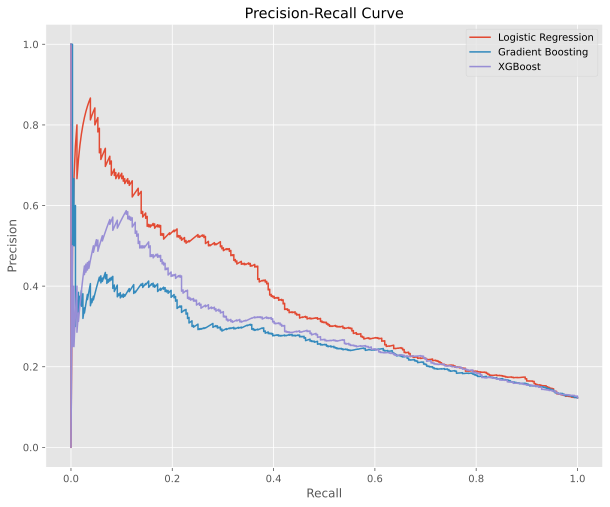

In [217]:
from sklearn.metrics import precision_recall_curve

lr_prec, lr_rec, _ = precision_recall_curve(y_val, lr_probs)
gb_prec, gb_rec, _ = precision_recall_curve(y_val, gb_probs)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_val, xgb_probs)

plt.figure(figsize=(10,8))

plt.plot(lr_rec, lr_prec, label="Logistic Regression")
plt.plot(gb_rec, gb_prec, label="Gradient Boosting")
plt.plot(xgb_rec, xgb_prec, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

Default Capture Curve (Cumulative Gains Curve)

In [220]:
## creating helper function

def default_capture_curve(y_true, scores):
    
    df = pd.DataFrame({
        "actual_default": y_true,
        "score": scores
    })
    
    # sort by highest risk first
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    
    # cumulative population %
    df["population_pct"] = np.arange(1, len(df)+1) / len(df)
    
    # cumulative captured defaults
    df["cum_defaults"] = df["actual_default"].cumsum()
    
    total_defaults = df["actual_default"].sum()
    
    df["capture_rate"] = df["cum_defaults"] / total_defaults
    
    return df

In [221]:
## generating capture data for each model

lr_capture  = default_capture_curve(y_val, lr_probs)
gb_capture  = default_capture_curve(y_val, gb_probs)
xgb_capture = default_capture_curve(y_val, xgb_probs)

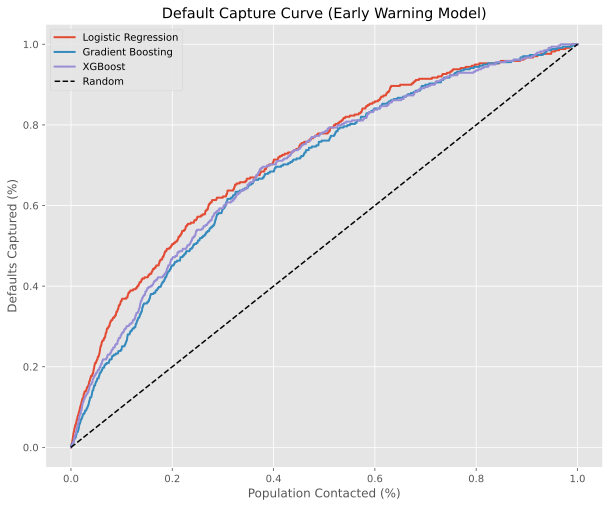

In [222]:
# Plot the capture curve

plt.figure(figsize=(10,8))

plt.plot(
    lr_capture["population_pct"],
    lr_capture["capture_rate"],
    label="Logistic Regression",
    linewidth=2
)

plt.plot(
    gb_capture["population_pct"],
    gb_capture["capture_rate"],
    label="Gradient Boosting",
    linewidth=2
)

plt.plot(
    xgb_capture["population_pct"],
    xgb_capture["capture_rate"],
    label="XGBoost",
    linewidth=2
)

# random baseline
plt.plot([0,1],[0,1], linestyle="--", color="black", label="Random")

plt.xlabel("Population Contacted (%)")
plt.ylabel("Defaults Captured (%)")
plt.title("Default Capture Curve (Early Warning Model)")
plt.legend()

plt.show()

### Model Comparison and Performance
- Logistic Regression model has outperformed both XGBoost and GradientBoost Classifier thus I have selected it as the final model. 

---

### Computing Recall@Top5%

In [239]:
total_defaulters = val_results["actual_default"].sum()
captured_defaulters = val_results.loc[val_results["top_5_flag"] == 1, "actual_default"].sum()

recall_at_5 = captured_defaulters / total_defaulters if total_defaulters > 0 else 0

print(f"Total defaulters in validation: {total_defaulters:,}")
print(f"Defaulters captured in top 5%: {captured_defaulters:,}")
print(f"Recall@Top5%: {recall_at_5:.2%}")

Total defaulters in validation: 339
Defaulters captured in top 5%: 69
Recall@Top5%: 20.35%


## QUESTION 1: How many defaulters captured in top 5% risk?

In [241]:
# compute recall@Top5%
print(f"Recall@Top5%: {recall_at_5:.2%}")


Recall@Top5%: 20.35%


From the above computation, contacting the top 5% highest-risk customers captures more than 20% of all future defaults. Therefore, this enables the collections team to focus limited outreach capacity on the riskiest portion of the portfolio while identifying a meaningful share of upcoming defaults.

## QUESTION 2: Mention at least 2 failure modes and how you’d monitor drift.

### Failure mode 1 — Data drift
- Customer behavior may change due to economic shocks, policy changes, and also introduction of new products. 

###  Failure mode 1 Monitoring
To monitor customer behavior change, I would do the below:
- (a) monitoring score distribution drift
- (b) tracking AUC/ Recall @Top5% by month

---

### Failure mode 2 — Feature availability issues
- Some variables may be updated after snapshot_date, creating leakage. 

###  Failure mode 1 Monitoring
To monitor customer behavior change, I would do the below:
- (a) auditing the feature timestamps to check for any changes.
- (b) comparing features before and after every close of the month. 
- (c) enforcing as-of data pipelines

---

## 10 SCORING DATA
### 10.1 Preparing the scoring data

In [205]:
# copying dataset to avoid modifying original
score_df = scoring_df.copy()

# ensure snapshot_date format
score_df["snapshot_date"] = pd.to_datetime(score_df["snapshot_date"])

# create same feature used during training
score_df["year_month"] = score_df["snapshot_date"].dt.to_period("M")

In [247]:
score_df.shape

(4659, 33)

### 10.2 Remove non-predictive columns and One-hot encode features

In [207]:
drop_cols = ["customer_id", "snapshot_date", "year_month"]

X_score_raw = score_df.drop(columns=drop_cols)

X_score = pd.get_dummies(X_score_raw, drop_first=True)

### 10.3 Align scoring columns to training columns and deal with leakage columns

In [ ]:
X_score.isna().sum().sort_values(ascending=False).head(20)
X_score = X_score.fillna(0)

### 10.4 Generate predicted probabilities
Using the trained logistic regression model

In [ ]:
score_probs = log_reg.predict_proba(X_score)[:, 1]

### 10.5 Generate predictions file

In [ ]:
# generating the prediction file
predictions = score_df[["customer_id","snapshot_date"]].copy()

predictions["pred_default_next_90d"] = score_probs

predictions.to_csv("predictions.csv", index=False)

print(predictions.head())

  customer_id snapshot_date  pred_default_next_90d
0      C00036    2025-01-01                   0.32
1      C00044    2025-01-01                   0.23
2      C00057    2025-01-01                   0.26
3      C00139    2025-01-01                   0.31
4      C00150    2025-01-01                   0.26


In [ ]:
# sanity check of predicted data to make sure the probabilities are between 0 and 1
print(predictions.shape)
print(predictions["pred_default_next_90d"].describe())

(4659, 4)
count   4,659.00
mean        0.50
std         0.22
min         0.09
25%         0.32
50%         0.47
75%         0.66
max         1.00
Name: pred_default_next_90d, dtype: float64


---
## Conclusion

The developed early-warning model successfully identifies customers likely to default within the next 90 days using only information available at the snapshot date.

By focusing on the **top 5% highest-risk customers**, UBA Kenya can detect over **20% of future defaults**, enabling proactive collections strategies and improved credit risk management.

## Recommendations 
### Business Use of the Early Warning Model

The predicted risk scores can support multiple operational actions within UBA Kenya’s retail credit portfolio as below:

1. **Collections prioritization**  
   Customers ranked in the top 5% risk segment can be prioritized for proactive outreach by collections or relationship managers.

2. **Credit limit management**  
   For revolving credit products, high-risk customers may have their credit limits reviewed or temporarily reduced to limit additional exposure.

3. **Early restructuring discussions**  
   Customers flagged as high risk may benefit from early engagement to explore repayment plans or restructuring options before accounts enter serious delinquency.


The model provides a ranked risk list that enables UBA Kenya to prioritize collections outreach, manage revolving credit exposure, and initiate early restructuring discussions with customers likely to default. 

---
### AUTHOR: Vincent Mbira
### DATE: 05-03-2026
---